# Probability, Entropy, and Inference

In [2]:
import pymc as pm
import pytensor
from pytensor.tensor import TensorVariable, TensorConstant
import arviz as az
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
from typing import List, Dict
from dataclasses import dataclass
from functools import reduce

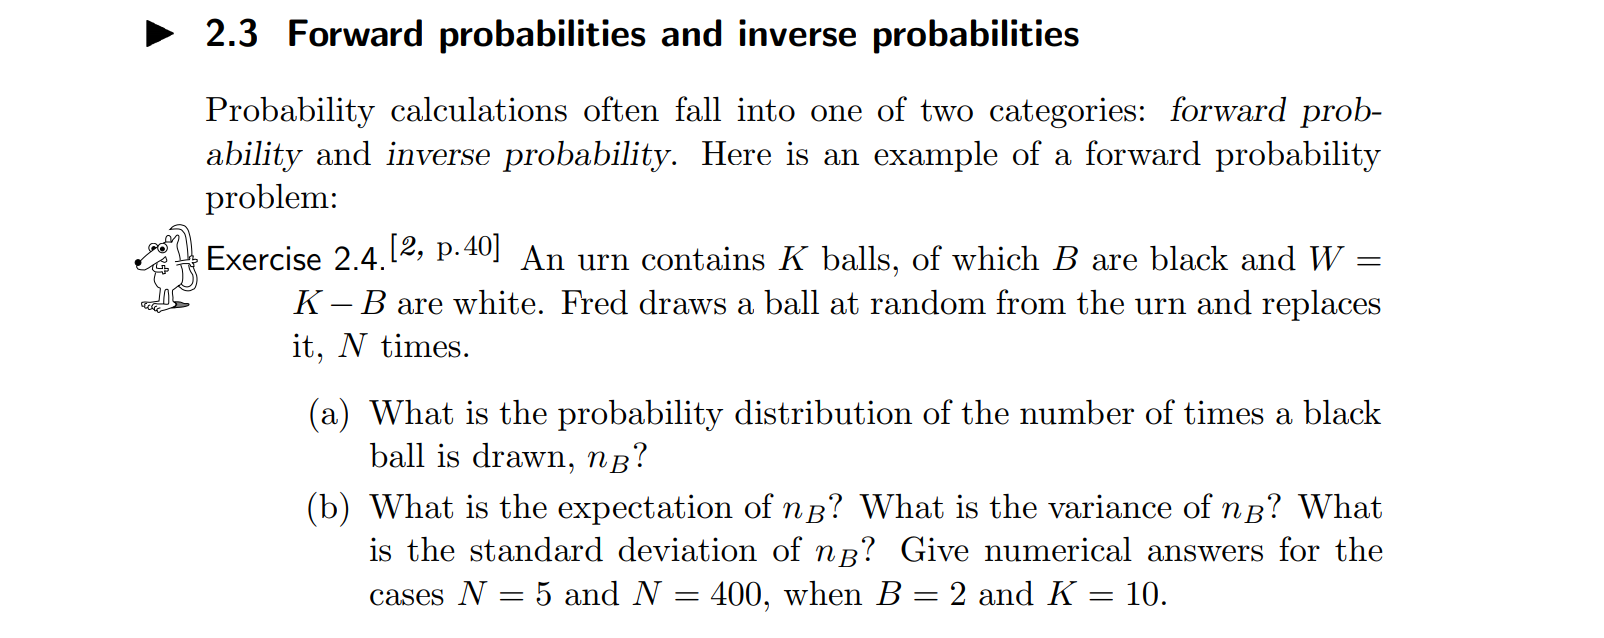

$$ P(n_B | B, K) = {K \choose B} \frac{B}{K}^{n_B}\frac{W}{K}^{K-n_B} $$

$$ 
\begin{align}
E[n_B] &= np = K\frac{B}{K} = B \\
V[n_B] &= E[n_B^2] - E[n_B]^2 = B^2

\end{align}


Expected Value: 2.0
Variance: 1.6000000000000003
Standard Deviation: 1.2649110640673518
Expected Value from LL: 2.0000000000000013
Expected Variance from LL: 1.600000000000001



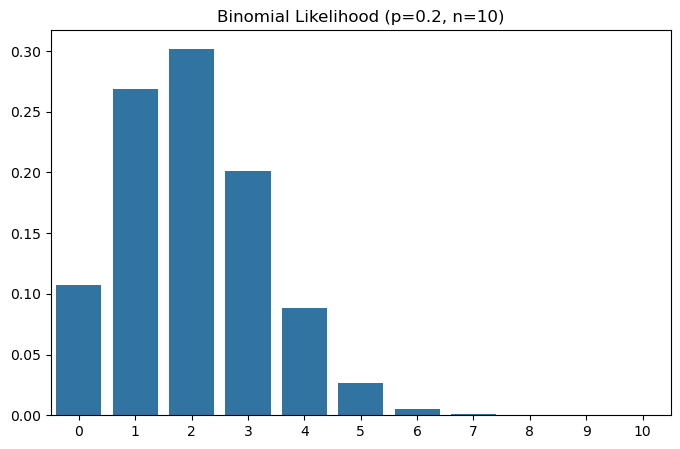

In [3]:
# (b)

@dataclass
class Combinatorial:

    @staticmethod
    def factorial(val: int) -> int:
        if val < 0:
            raise ValueError("val must be a positive integer")
        if val <= 1:
            return 1

        agg: int = 1
        factor: int = val
        for v in range(val, 0, -1):
            agg *= factor
            factor -= 1

        return agg
        
    @staticmethod
    def binomial_combinations(n: int, k: int) -> int:
        num: int = Combinatorial.factorial(n)
        denom: int = Combinatorial.factorial(k) * Combinatorial.factorial(n - k)
        return num / denom

    @staticmethod
    def multinomial_combinations(cnts_by_state: Dict[int, int]) -> int:
        state_cnts: List[int] = list(cnts_by_state.values())
        num: int = Combinatorial.factorial(sum(state_cnts))
        denom: int = reduce(
            lambda x, y: x * y,
            [Combinatorial.factorial(sc) for sc in state_cnts]
        )
        return num / denom

@dataclass
class Binomial:
    p: float

    @staticmethod
    def from_population(k: int, n: int) -> "Binomial":
        if n <= 0:
            raise ValueError("trials must be a positive integer")
        if k < 0 or k > n:
            raise ValueError("successes must be between 0 and trials")
        return Binomial(p=k / n)

    def p_likelihood(self, n: int, k: int) -> float:
        success_prob: float = self.p ** k
        failure_prob: float = (1 - self.p) ** (n - k)
        return success_prob * failure_prob

    def c_likelihood(self, n: int, k: int) -> float:
        combs: int = Combinatorial.binomial_combinations(n, k)
        return combs * self.p_likelihood(n, k)

    def ll(self, n: int) -> Dict[int, float]:
        return {k: self.c_likelihood(n, k) for k in range(n + 1)}

    def expected_value(self, n: int) -> float:
        return n * self.p

    def variance(self, n: int) -> float:
        return n * (self.p * (1 - self.p))

    def standard_deviation(self, n: int) -> float:
        return self.variance(n) ** 0.5

    def expected_value_from_ll(self, n: int) -> float:
        ll: Dict[int, float] = self.ll(n)
        return sum([k * p for k, p in ll.items()])

    def variance_from_ll(self, n: int) -> float:
        ll: Dict[int, float] = self.ll(n)
        ev: float = self.expected_value_from_ll(n)
        ev_deviation: Callable[[int, float], float] = lambda k, p: ((k - ev) ** 2) * p
        return sum([ev_deviation(k, p) for k, p in ll.items()])

    def sample(self, n_sample: int) -> List[int]:
        return np.random.binomial(n=1, p=self.p, size=n_sample).tolist()

    def expected_value_from_sample(self, sample: List[int]) -> float:
        return sum(sample) / len(sample) 

    def variance_from_sample(self, sample: List[int]) -> float:
        ev: float = self.expected_value_from_sample(sample)
        ev_deviation: Callable[[int], float] = lambda k: (k - ev) ** 2
        return sum([ev_deviation(k) for k in sample]) / len(sample)

    def plot_ll(self, n: int) -> plt.Figure:
        ll: Dict[int, float] = self.ll(n)
        fig, ax = plt.subplots(figsize=(8, 5))
        sb.barplot(x=list(ll.keys()), y=list(ll.values()), ax=ax)
        ax.set_title(f"Binomial Likelihood (p={self.p}, n={n})")

n_b: int = 2
n_total: int = 10
b: Binomial = Binomial.from_population(k=n_b, n=n_total)
binomial_stats: str = f"""
Expected Value: {b.expected_value(n_total)}
Variance: {b.variance(n_total)}
Standard Deviation: {b.standard_deviation(n_total)}
Expected Value from LL: {b.expected_value_from_ll(n_total)}
Expected Variance from LL: {b.variance_from_ll(n_total)}
"""
print(binomial_stats)
b.plot_ll(n_total)


In [4]:
sample_1: List[int] = b.sample(5)
sample_2: List[int] = b.sample(400)
binomial_sample_stats: str = f"""
Sample #1 (N=5)
================
Expected Value = {b.expected_value_from_sample(sample_1)}
Variance = {b.variance_from_sample(sample_1)}

Sample #2 (N=400)
================
Expected Value = {b.expected_value_from_sample(sample_2)}
Variance = {b.variance_from_sample(sample_2)}
"""
print(binomial_sample_stats)


Sample #1 (N=5)
Expected Value = 0.0
Variance = 0.0

Sample #2 (N=400)
Expected Value = 0.2
Variance = 0.15999999999999948



What if we were using PyMC to solve this problem? How would we set this up? As above, $B$ and $W$ are given, as is the number of draws $N$. Our goal is to understand the probability distribution of $n_b$.

Multiprocess sampling (4 chains in 4 jobs)
Metropolis: [n_b]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 0 seconds.


binomial_rv{"(),()->()"}.1 [id A] 'n_b'
 ├─ RNG(<Generator(PCG64) at 0x3044657E0>) [id B]
 ├─ NoneConst{None} [id C]
 ├─ n [id D]
 └─ ExpandDims{axis=0} [id E]
    └─ Identity [id F] 'p'
       └─ True_div [id G]
          ├─ b [id H]
          └─ Add [id I]
             ├─ b [id H]
             └─ w [id J]


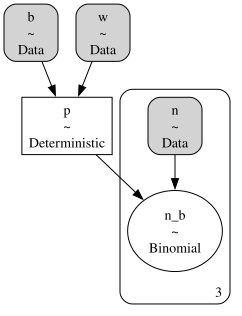

In [33]:
with pm.Model() as ex2_3:
    b: TensorConstant = pm.Data("b", 2)
    w: TensorConstant = pm.Data("w", 8)
    n: TensorConstant = pm.Data("n", [5, 10, 400])
    p: TensorConstant = pm.Deterministic("p", b / (b + w))
    ex2_3_n_b: TensorVariable = pm.Binomial("n_b", n=n, p=p)
    ex2_3_trace: az.InferenceData = pm.sample(1000, return_inferencedata=True)

pytensor.dprint(ex2_3_n_b)
pm.model_to_graphviz(ex2_3)

Now that we have sampled from the posterior distribution, computing the expected values, variances, and standard deviations is a simple matter. They can be computed directly from the samples. Note that we have generated samples of size 1000 for each of the chains. We can just compute over all chains.

In [ ]:
print(f' Expected Value: {(ex2_3_trace.posterior["n_b"].mean(dim=["chain", "draw"]) / [5, 10, 400]).values}')
print(f' Variance: {(ex2_3_trace.posterior["n_b"].var(dim=["chain", "draw"]) / [5, 10, 400]).values}')
print(f' Standard Deviation: {(ex2_3_trace.posterior["n_b"].std(dim=["chain", "draw"]) / [5, 10, 400]).values}')

 Expected Value: [0.20005    0.1959     0.19970312]
 Variance: [0.15854999 0.1613819  0.15376412]
 Standard Deviation: [0.17807301 0.12703618 0.01960638]


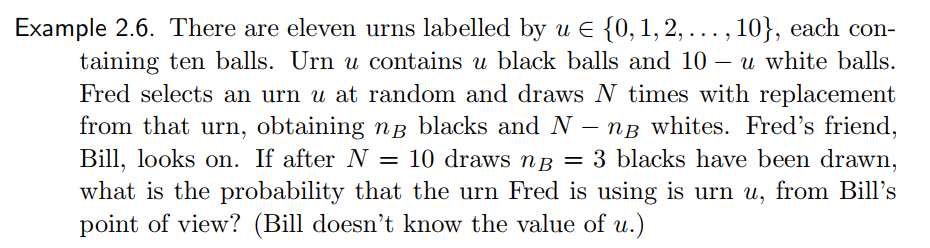

This one actually hung me up a bit because it's not obvious what to do with $N$. What is the probability of $N$ when $N$ is not actually a random variable. It's just a parameter that is given. So we need to be able to condition on it throughout. We will only ever operate on the distribution of $P(u)$ even though $N$ is hanging out as understood knowledge upon which we condition.

$$ P(u | n_b, N) = \frac{P(n_b | u, N) P(u)}{P(n_b | N)} $$

Now we can start to break each part down. The prior is most straightforward because it's just a uniform draw across all available urns.

$$ P(u) = \frac{1}{11} $$

The likelhood is distributed binomially for each value in the prior distribution.

$$ P(n_b | u, N) = {N \choose n_b} \frac{u}{10}^{n_b}\frac{10-u}{10}^{N - n_b} $$

But what about the evidence $P(n_b | N)$? The number of draws cannot govern how many black balls are in each urn, but it can determine the number that we actually see. If $N=2$, how could we possible observe $n_b = 3$? But, again, $N$ is not a random variable. It's a known number so there is only one case to deal with. We just need to account for all of the probabilities of $n_b$ for each case $u$ to normalize the distribution. In other words, it's the expected value of the likelihoods marginalized over $u$.

$$ P(n_b | N) = \Sigma_{u=0}^{11} P(n_b | u, N) P(u) = \Sigma_{u=0}^{11} {N \choose n_b} \frac{u}{10}^{n_b}\frac{10-u}{10}^{N - n_b} \frac{1}{11}$$

Putting it all together.

$$ P(u | n_b, N) = \frac{{N \choose n_b} \frac{u}{10}^{n_b}\frac{10-u}{10}^{N - n_b} \frac{1}{11}}{\Sigma_{u=0}^{11} {N \choose n_b} \frac{u}{10}^{n_b}\frac{10-u}{10}^{N - n_b} \frac{1}{11}} $$


To compute this, it will be convenient to make a function parametricin $u$. Doing so provides some intuition around what the posterior really is. We are just looking at the likelihood for each case $u$ relative to the aggregate likelihood for all cases of $u$. It's just the ratio for each value of $u$ (most easily seen in `posterior_by_u()`).

In [5]:
def bin_ll_from_u(u: int) -> float:
    n_b: int = 3
    N: int = 10
    b: Binomial = Binomial(p=u/10.)
    return b.c_likelihood(n=N, k=n_b)

def posterior_by_u(u: int) -> float:
    numerator: float = bin_ll_from_u(u) * (1/11.)
    denominator: float = sum([bin_ll_from_u(u_i) * (1/11.) for u_i in range(11)])
    return numerator / denominator

posterior_of_u: Dict[int, float] = {u_i: posterior_by_u(u_i) for u_i in range(11)}

posterior_of_u

{0: 0.0,
 1: 0.06307262464852745,
 2: 0.22123978796753002,
 3: 0.2932198598955793,
 4: 0.2362555743579042,
 5: 0.12877850558581408,
 6: 0.04666776777440085,
 7: 0.009892048584565579,
 8: 0.0008642179217481626,
 9: 9.613263930578772e-06,
 10: 0.0}

Again, what does this look like if we use PyMC. This time we are interested in reverse probability, because we don't know the parameter $u$. 

Sampling: [ex2_6_n_b, u]
Multiprocess sampling (4 chains in 4 jobs)
Metropolis: [u]


Output()

Sampling 4 chains for 1_000 tune and 100_000 draw iterations (4_000 + 400_000 draws total) took 14 seconds.


binomial_rv{"(),()->()"}.1 [id A] 'ex2_6_n_b'
 ├─ RNG(<Generator(PCG64) at 0x3045FF4C0>) [id B]
 ├─ [] [id C]
 ├─ n [id D]
 └─ Identity [id E] 'p'
    └─ True_div [id F]
       ├─ Cast{float64} [id G]
       │  └─ Identity [id H] 'b'
       │     └─ discrete_uniform_rv{"(),()->()"}.1 [id I] 'u'
       │        ├─ RNG(<Generator(PCG64) at 0x30451A7A0>) [id J]
       │        ├─ NoneConst{None} [id K]
       │        ├─ Floor [id L]
       │        │  └─ 0 [id M]
       │        └─ Floor [id N]
       │           └─ 10 [id O]
       └─ Add [id P]
          ├─ Identity [id H] 'b'
          │  └─ ···
          └─ Identity [id Q] 'w'
             └─ Sub [id R]
                ├─ n [id D]
                └─ discrete_uniform_rv{"(),()->()"}.1 [id I] 'u'
                   └─ ···


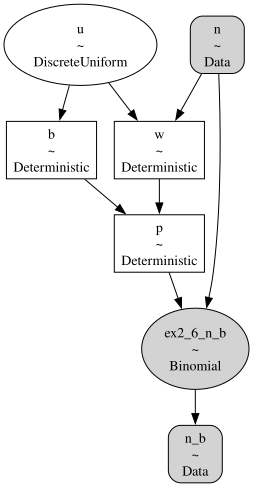

In [77]:
with pm.Model() as ex2_6:
    n: TensorConstant = pm.Data("n", np.array(10, dtype=np.int64))
    n_b: TensorConstant = pm.Data("n_b", np.array(3, dtype=np.int64))
    u: TensorVariable = pm.DiscreteUniform("u", lower=0, upper=10)
    b: TensorConstant = pm.Deterministic("b", u)
    w: TensorConstant = pm.Deterministic("w", n - u)
    p: TensorVariable = pm.Deterministic("p", b.astype(float) / (b + w))
    ex2_6_n_b: TensorVariable = pm.Binomial("ex2_6_n_b", n=n, p=p, observed=n_b)
    ex2_6_prior: az.InferenceData = pm.sample_prior_predictive(1000, return_inferencedata=True)
    # Note that we increase the sample size to get non-zero density across all relevant values of u
    ex2_6_trace: az.InferenceData = pm.sample(100000, return_inferencedata=True)
    
pytensor.dprint(ex2_6_n_b)
pm.model_to_graphviz(ex2_6)
    

Notice the similarity between the forward and inverse probability graphs. They are almost identical, except that we now have knowledge of different parts of the graph. We do know $n_b$, but we don't know $u$ which determines $b$ and $w$. Again, we have drawn from the posterior distribution, and this time we can examine $u$. Our approximation matches our exact computation from the Binomial distribution very closely.

In [78]:
values, counts = np.unique_counts(ex2_6_trace.posterior["u"].values)
dict(zip(values, counts / counts.sum()))

{np.int64(1): np.float64(0.0632725),
 np.int64(2): np.float64(0.220655),
 np.int64(3): np.float64(0.2930825),
 np.int64(4): np.float64(0.237315),
 np.int64(5): np.float64(0.1292625),
 np.int64(6): np.float64(0.04614),
 np.int64(7): np.float64(0.0094325),
 np.int64(8): np.float64(0.0008375),
 np.int64(9): np.float64(2.5e-06)}

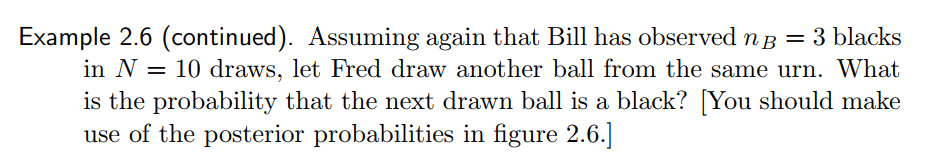

My first instinct was to compute $P(n_b=4, N=11 | u)$, but that's actually complicating the picture by trying to compute the total composition of draws. We actually already know that for each urn, the probability of selecting a black ball is just $\frac{u}{10}$ because we are sampling with replacement. So all that we need to do is compute the expected value across all values of $u$. We already have the posterior distribution of $u$, which is literally our best guess given the data we have observed so far. This time, $n_b$ and $N$ are both given parameters. The posterior for $u$ conditional on those parameters serves as the weights in our expected value calcuation.

$$ P(n_b \text{ += 1} | n_b, N) = \Sigma_{u=0}^{11} P(u | n_b, N) \frac{u}{10} $$

In [7]:
sum([posterior_of_u[u_i] * (u_i / 10.) for u_i in range(11)])

0.33303778151187374

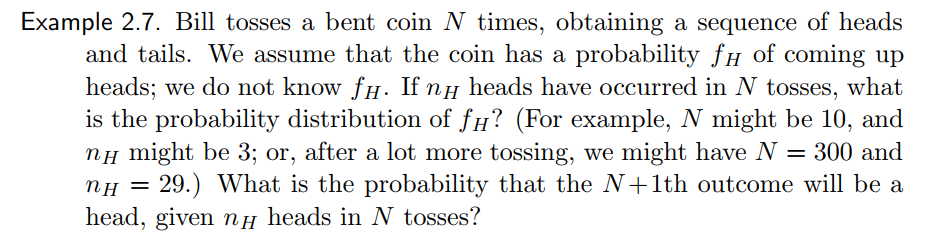

The first question is about an unobserved parameter $f_H$, so we should immediately be thinking inverse probability. 

$$ 
\begin{align}
P(f_H | n_H, N) &= \frac{P(n_H | f_H, N) P(f_H)}{P(n_H | N)} \\
&= \frac{{N \choose n_H} {f_H}^{n_H} {1 - f_H}^{N - n_H} \frac{1}{1-0}}{{N \choose n_H} \int_0^1 {f_H}^{n_H} {1 - f_H}^{N - n_H} df_H} \\
&= \frac{{f_H}^{n_H} {1 - f_H}^{N - n_H}}{\frac{(n_H)!(N - n_H)!}{(n_H + N - n_H + 1)!}} \\
&= \frac{(N+1)!}{(n_H)!(N - n_H)!}{f_H}^{n_H} {1 - f_H}^{N - n_H}
\end{align}
$$

Just as before $P(f_H | N) = P(f_H)$ because $f_H$ does not depend on $N$. Outside of that, it's exactly the same problem as 2.6 (now with the need to assume a prior). In this case, we can solve for it analytically. The uniform prior on $f_H$ interacting with a binomial likelihood yields the well known [Beta distribution](https://en.wikipedia.org/wiki/Beta_distribution).

Sampling: [ex2_7_n_b, p]
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Output()

Sampling 4 chains for 1_000 tune and 100_000 draw iterations (4_000 + 400_000 draws total) took 16 seconds.


binomial_rv{"(),()->()"}.1 [id A] 'ex2_7_n_b'
 ├─ RNG(<Generator(PCG64) at 0x305D09A80>) [id B]
 ├─ [] [id C]
 ├─ n [id D]
 └─ beta_rv{"(),()->()"}.1 [id E] 'p'
    ├─ RNG(<Generator(PCG64) at 0x305D07AE0>) [id F]
    ├─ NoneConst{None} [id G]
    ├─ 1 [id H]
    └─ 1 [id I]


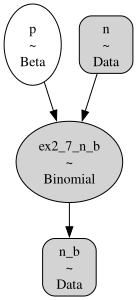

In [81]:
with pm.Model() as ex2_7:
    n: TensorConstant = pm.Data("n", np.array(10, dtype=np.int64))
    n_b: TensorConstant = pm.Data("n_b", np.array(3, dtype=np.int64))
    p: TensorVariable = pm.Beta("p", 1, 1)
    ex2_7_n_b: TensorVariable = pm.Binomial("ex2_7_n_b", n=n, p=p, observed=n_b)
    ex2_7_prior: az.InferenceData = pm.sample_prior_predictive(1000, return_inferencedata=True)
    # Note that we increase the sample size to get non-zero density across all relevant values of u
    ex2_7_trace: az.InferenceData = pm.sample(100000, return_inferencedata=True)
    
pytensor.dprint(ex2_7_n_b)
pm.model_to_graphviz(ex2_7)
    

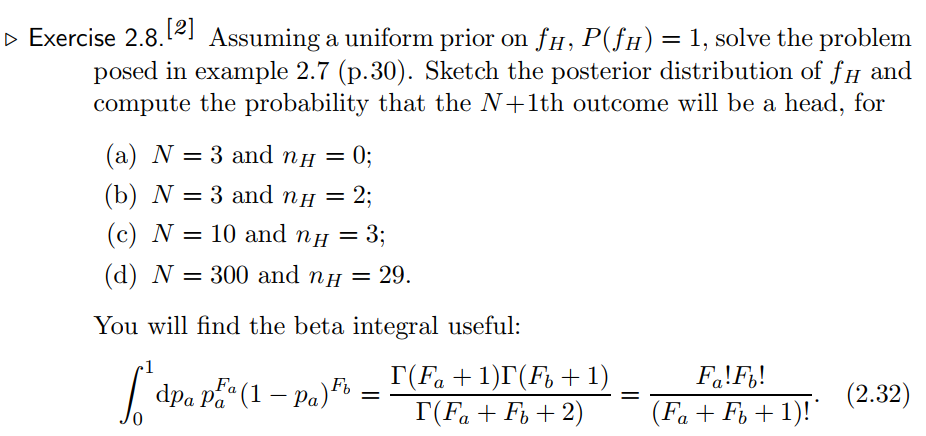

The [Beta integral](https://en.wikipedia.org/wiki/Beta_distribution#Probability_density_function) is useful here because it will make our evidence expression much easier to deal with, which is why we used it for the analytic solution above. For the numeric examples, let's use PyMC to approximate.

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [f_h]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 2 seconds.
Initializing NUTS using jitter+adapt_diag...


P(head next | n_H=0, N=3) = 0.2


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [f_h]


...

Multiprocess sampling (4 chains in 4 jobs)
NUTS: [f_h]


Output()

Sampling 4 chains for 1_000 tune and 10_000 draw iterations (4_000 + 40_000 draws total) took 2 seconds.


P(head next | n_H=29, N=300) = 0.09933774834437085


<Axes: title={'center': 'Posterior of f_H given n_H=29 and N=300'}, xlabel='f_H', ylabel='Density'>

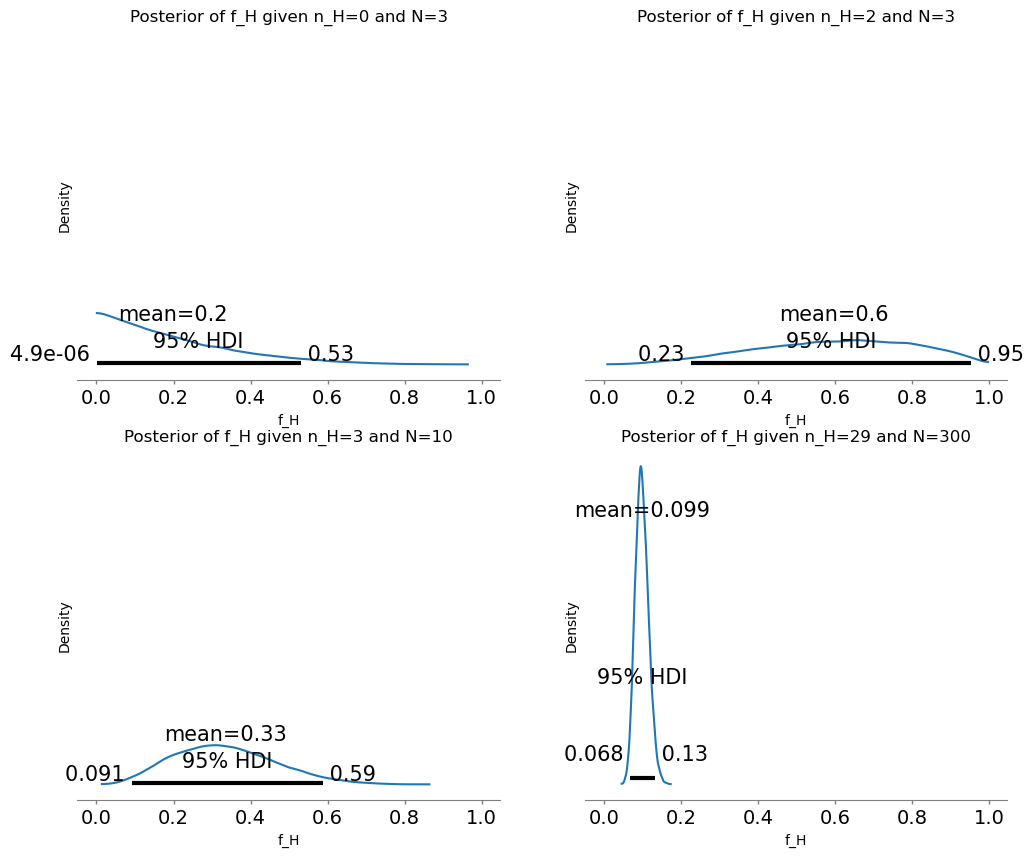

In [89]:
def posterior_plot_and_p_head_next(n_h: int, n: int, ax: plt.Axes, n_draws: int = 10000) -> plt.Axes:
    with pm.Model() as ex2_8:
        n_h_d: TensorConstant = pm.Data("n_h", np.array(n_h, dtype=np.int64))
        n_d: TensorConstant = pm.Data("n", np.array(n, dtype=np.int64))
        f_h: TensorVariable = pm.Uniform("f_h", lower=0, upper=1)
        ex2_8_n_h: TensorVariable = pm.Binomial("ex2_8_n_h", n=n_d, p=f_h, observed=n_h_d)
        ex2_8_trace: az.InferenceData = pm.sample(n_draws, return_inferencedata=True)

    az.plot_posterior(ex2_8_trace, var_names=["f_h"], hdi_prob=0.95, ax=ax)
    ax.set_title(f"Posterior of f_H given n_H={n_h} and N={n}")
    ax.set_xlabel("f_H")
    ax.set_ylabel("Density")
    
    p_head_next: float = (n_h + 1) / (n + 2)
    print(f"P(head next | n_H={n_h}, N={n}) = {p_head_next}")
    
    return ax

fig, ax = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
posterior_plot_and_p_head_next(n_h=0, n=3, ax=ax[0, 0])
posterior_plot_and_p_head_next(n_h=2, n=3, ax=ax[0, 1])
posterior_plot_and_p_head_next(n_h=3, n=10, ax=ax[1, 0])
posterior_plot_and_p_head_next(n_h=29, n=300, ax=ax[1, 1])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [f_h]


Output()

Sampling 4 chains for 1_000 tune and 100 draw iterations (4_000 + 400 draws total) took 0 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...


P(head next | n_H=3, N=10) = 0.3333333333333333


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [f_h]


...

Multiprocess sampling (4 chains in 4 jobs)
NUTS: [f_h]


Output()

Sampling 4 chains for 1_000 tune and 100_000 draw iterations (4_000 + 400_000 draws total) took 16 seconds.


P(head next | n_H=3, N=10) = 0.3333333333333333


<Axes: title={'center': 'Posterior of f_H given n_H=3 and N=10'}, xlabel='f_H', ylabel='Density'>

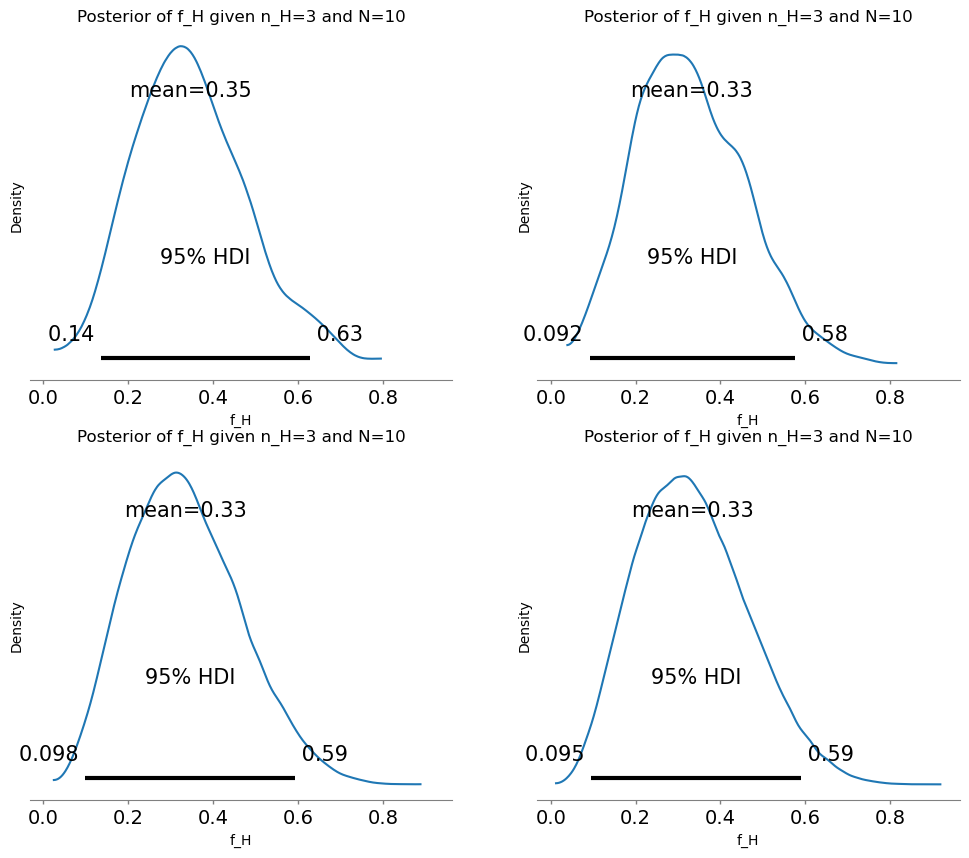

In [90]:
fig, ax = plt.subplots(2, 2, figsize=(12, 10), sharex=True, sharey=True)
posterior_plot_and_p_head_next(n_h=3, n=10, ax=ax[0, 0], n_draws=100)
posterior_plot_and_p_head_next(n_h=3, n=10, ax=ax[0, 1], n_draws=1000)
posterior_plot_and_p_head_next(n_h=3, n=10, ax=ax[1, 0], n_draws=10000)
posterior_plot_and_p_head_next(n_h=3, n=10, ax=ax[1, 1], n_draws=100000)

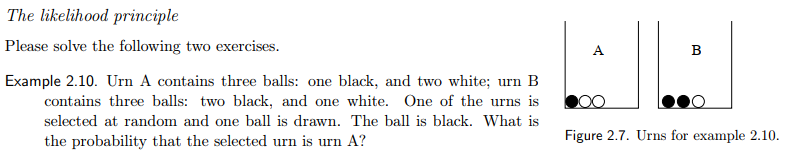

Just as before, we are trying to identify the urn, but the set up of this problem is suggestive of how we do hypothesis testing in a Bayesian framework. We have two (or more) states of the world, and our task is to determine which state of the world is more consistent with the data we observe. 

$$
\begin{align}

P(u|B) &= \frac{P(B|u) P(u)}{P(B)} \\
 &= \frac{{n \choose n_b} (\frac{n_b}{n_b + n_w})^{n_b} (\frac{n_w}{n_b + n_w})^{n-n_b} P(u)}{\Sigma_u {n \choose n_b} (\frac{n_b}{n_b + n_w})^{n_b} (\frac{n_w}{n_b + n_w})^{n-n_b}} \\
 &= \frac{{1 \choose 1} (\frac{1}{3})^{1} (\frac{2}{3})^{0} \frac{1}{2}}{{1 \choose 1} (\frac{1}{3})^{1} (\frac{2}{3})^{0} \frac{1}{2} + {1 \choose 1} (\frac{2}{3})^{1} (\frac{1}{3})^{0} \frac{1}{2}} \\
 &= \frac{\frac{1}{6}}{\frac{1}{6} + \frac{2}{6}} \\
 &= \frac{1}{3}

 \end{align}
$$

 If we had many hypotheses, one could imagine evaluating each one $u \in \{A, B, C, \dots \}$ and then ordering them according to their posterior probabilities. In the case of two complementary outcomes, however, we can also just compute the odds to determine the more likely outcome.

 $$
 \begin{align}
 
 \frac{P(u_a|B)}{P(u_b|B)} &= \frac{P(B|u_a)}{P(B|u_b)} \frac{P(u_a)}{P(u_b)} \\
&= \frac{P(B|u_a)}{P(B|u_b)} \\
&= \frac{\frac{1}{3}}{\frac{2}{3}} \\
&= \frac{1}{2}

 \end{align}
 $$

 That is, urn $A$ is half as likely as urn $B$ to yield a black ball after only one draw. This comports with our first answer: if the probability of urn $A$ is one-third given one ball drawn being black, the rest of that probability mass (i.e. two-thirds) must correspond to urn $B$. 

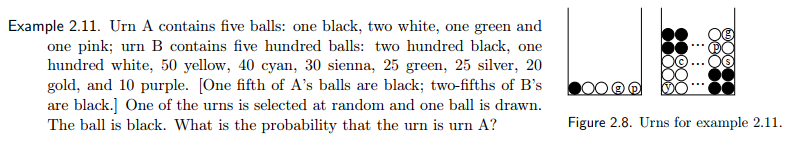

The same logic from 2.10 holds in 2.11. The only difference is that instead of partitioning between black and white balls, we partition between black and non-black balls. All other colors are defined as the complementary set, and the mechanics otherwise remain the same.